# Market Regime Detection — Exploration

This notebook:
- downloads daily SPY data (Stooq)
- builds return/volatility/trend features
- creates a simple 4-regime label (trend x volatility)
- visualizes regimes

In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas_datareader import data as pdr

pd.set_option("display.max_columns", 50)

In [16]:
def load_spy(start="2005-01-01", end=None):
    # S&P 500 ETF
    df = pdr.DataReader("spy.us", "stooq", start=start, end=end)
    df = df.sort_index()  # ensure chronological order
    df.index = pd.to_datetime(df.index)
    return df

df = load_spy(start="2005-01-01")
df.head(), df.tail(), df.shape

(               Open     High      Low    Close    Volume
 Date                                                    
 2005-02-25  92.7949  93.8716  92.7097  93.6948  79289004
 2005-02-28  93.4735  93.5952  92.6083  93.0544  89985785
 2005-03-01  93.1845  93.7683  93.1845  93.5386  61658442
 2005-03-02  93.1749  94.0766  93.0735  93.4927  83253671
 2005-03-03  93.8716  94.0575  93.1203  93.5301  80491538,
               Open    High     Low   Close     Volume
 Date                                                 
 2026-02-25  690.18  693.68  690.10  693.15   56369500
 2026-02-26  693.28  693.30  684.35  689.30   71080843
 2026-02-27  683.09  686.86  681.64  685.99   83072210
 2026-03-02  678.70  688.62  678.02  686.38   87477198
 2026-03-03  675.06  682.61  669.66  680.33  105003113,
 (5286, 5))

In [17]:
df.isna().sum(), df.describe()

(Open      0
 High      0
 Low       0
 Close     0
 Volume    0
 dtype: int64,
               Open         High          Low        Close        Volume
 count  5286.000000  5286.000000  5286.000000  5286.000000  5.286000e+03
 mean    233.682087   234.973454   232.269617   233.717208  1.486593e+08
 std     160.997036   161.781795   160.123450   161.032505  1.187588e+08
 min      52.424500    54.007400    51.770700    52.549800  1.979157e+07
 25%     103.753500   104.372750   102.939000   103.595750  7.298396e+07
 50%     174.987000   175.890500   174.086000   174.854000  1.063975e+08
 75%     338.424500   340.470000   336.545250   339.796250  1.841454e+08
 max     697.050000   697.840000   693.940000   695.490000  1.129619e+09)

In [18]:
data = df.copy()

# Daily log returns
data["ret_1d"] = np.log(data["Close"]).diff()

# Rolling volatility (annualized-ish scaling not required for ML, but okay to keep as raw)
data["vol_20d"] = data["ret_1d"].rolling(20).std()

# Trend proxy: past 60d return (log)
data["trend_60d"] = np.log(data["Close"]).diff(60)

# Momentum features
data["mom_5d"] = np.log(data["Close"]).diff(5)
data["mom_20d"] = np.log(data["Close"]).diff(20)

# Range / intraday movement proxies
data["hl_range"] = (data["High"] - data["Low"]) / data["Close"]
data["co_return"] = (data["Close"] - data["Open"]) / data["Open"]

# Volume change
data["volchg_5d"] = np.log(data["Volume"]).diff(5)

data = data.dropna().copy()
data.head()

,Open,High,Low,Close,Volume,ret_1d,vol_20d,trend_60d,mom_5d,mom_20d,hl_range,co_return,volchg_5d
Date,,,,,,,,,,,,,
2005-05-23,91.9843,92.6083,91.9651,92.4159,66482810,0.005491,0.007601,-0.013744,0.025159,0.029265,0.006960,0.004692,0.038610
2005-05-24,92.1567,92.4630,91.9749,92.2142,66100846,-0.002185,0.007194,-0.009070,0.016462,0.036801,0.005293,0.000624,-0.185874
2005-05-25,92.1010,92.4906,91.6895,92.1394,62840231,-0.000811,0.007199,-0.015072,0.005301,0.032069,0.008694,0.000417,-0.476169
2005-05-26,92.4256,92.7385,92.2973,92.6160,56457030,0.005159,0.006404,-0.009421,0.006179,0.049854,0.004764,0.002060,-0.366639
2005-05-27,92.6248,92.7771,92.4351,92.7771,31938170,0.001738,0.005853,-0.008083,0.009392,0.038064,0.003686,0.001644,-0.633398


In [19]:
# Define high volatility threshold (e.g., 70th percentile across the whole sample)
vol_thresh = data["vol_20d"].quantile(0.70)

data["vol_regime"] = np.where(data["vol_20d"] >= vol_thresh, "high_vol", "low_vol")
data["trend_regime"] = np.where(data["trend_60d"] >= 0, "up_trend", "down_trend")

def combine_regime(trend, vol):
    if trend == "up_trend" and vol == "low_vol":
        return "bull_calm"
    if trend == "up_trend" and vol == "high_vol":
        return "bull_volatile"
    if trend == "down_trend" and vol == "low_vol":
        return "bear_calm"
    return "bear_volatile"

data["regime"] = [combine_regime(t, v) for t, v in zip(data["trend_regime"], data["vol_regime"])]

data["regime"].value_counts(normalize=True).round(3)

regime
bull_calm        0.621
bear_volatile    0.187
bull_volatile    0.113
bear_calm        0.079
Name: proportion, dtype: float64

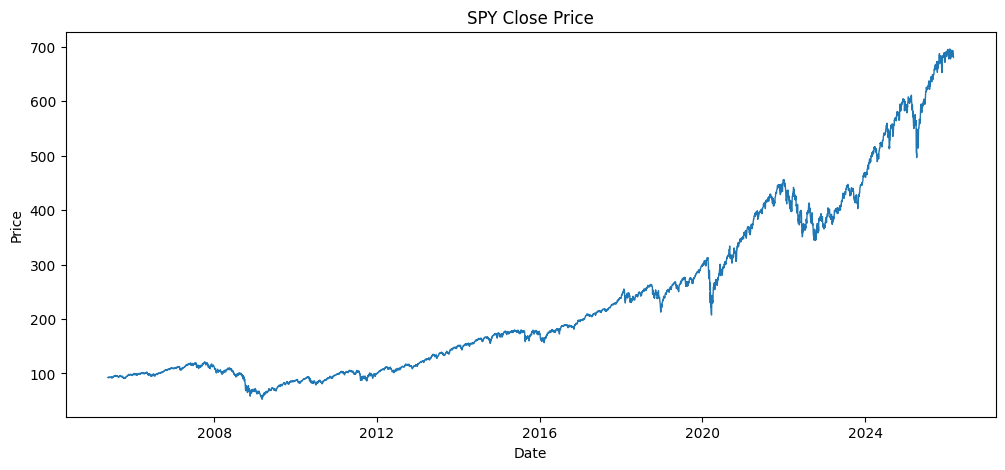

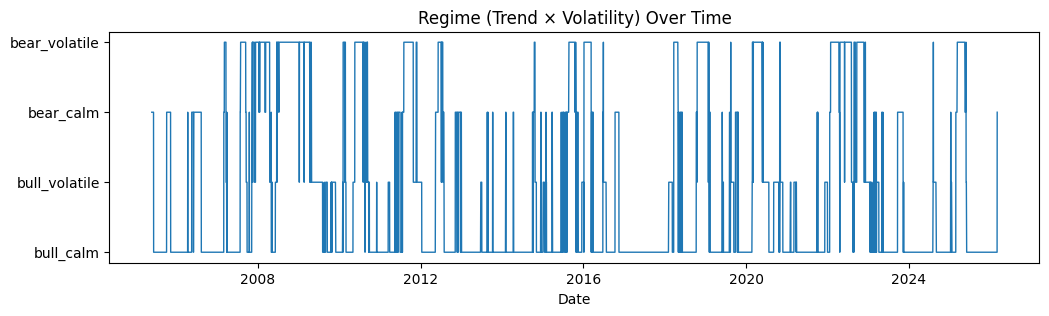

In [20]:
# Create a numeric code for regimes for plotting convenience
regime_order = ["bull_calm", "bull_volatile", "bear_calm", "bear_volatile"]
regime_to_code = {r:i for i, r in enumerate(regime_order)}
data["regime_code"] = data["regime"].map(regime_to_code)

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"], linewidth=1)
plt.title("SPY Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(data.index, data["regime_code"], linewidth=1)
plt.yticks(range(len(regime_order)), regime_order)
plt.title("Regime (Trend × Volatility) Over Time")
plt.xlabel("Date")
plt.show()

In [21]:
HORIZON = 20  # 20 trading days ahead

data["target_regime_tplus"] = data["regime"].shift(-HORIZON)

# Drop last HORIZON rows that don't have a target
ml_df = data.dropna(subset=["target_regime_tplus"]).copy()

ml_df[["Close", "ret_1d", "vol_20d", "trend_60d", "target_regime_tplus"]].tail()

,Close,ret_1d,vol_20d,trend_60d,target_regime_tplus
Date,,,,,
2026-01-27,695.49,0.003976,0.006749,0.011715,bull_calm
2026-01-28,695.42,-0.000101,0.006687,0.022673,bull_calm
2026-01-29,694.04,-0.001986,0.006700,0.017412,bull_calm
2026-01-30,691.97,-0.002987,0.006492,0.012550,bull_calm
2026-02-02,695.41,0.004959,0.006558,0.029433,bear_calm


In [22]:
feature_cols = [
    "ret_1d", "vol_20d", "trend_60d", "mom_5d", "mom_20d",
    "hl_range", "co_return", "volchg_5d"
]

X = ml_df[feature_cols].copy()
y = ml_df["target_regime_tplus"].copy()

X.shape, y.value_counts()

((5206, 8),
 target_regime_tplus
 bull_calm        3235
 bear_volatile     977
 bull_volatile     591
 bear_calm         403
 Name: count, dtype: int64)

In [23]:
# A simple chronological split preview
split_idx = int(len(ml_df) * 0.8)
train_end_date = ml_df.index[split_idx]

print("Train ends:", train_end_date.date())
print("Test starts:", ml_df.index[split_idx + 1].date())

Train ends: 2021-12-07
Test starts: 2021-12-08
